## Call Option: Time Value Decay

**Under assumption that rates are constant near 0**

**Key insight**: As maturity T → 0, the option price converges to the payoff max(S - K, 0)

- **Blue**: Payoff at expiry
- **Red curves**: Option prices (darker = longer maturity)
- More time = more time value above the payoff

**If rates are flat, the PV of the option converges to the payoff at expiry.**

If rates are flat, the PV of the option converges to the payoff at expiry.


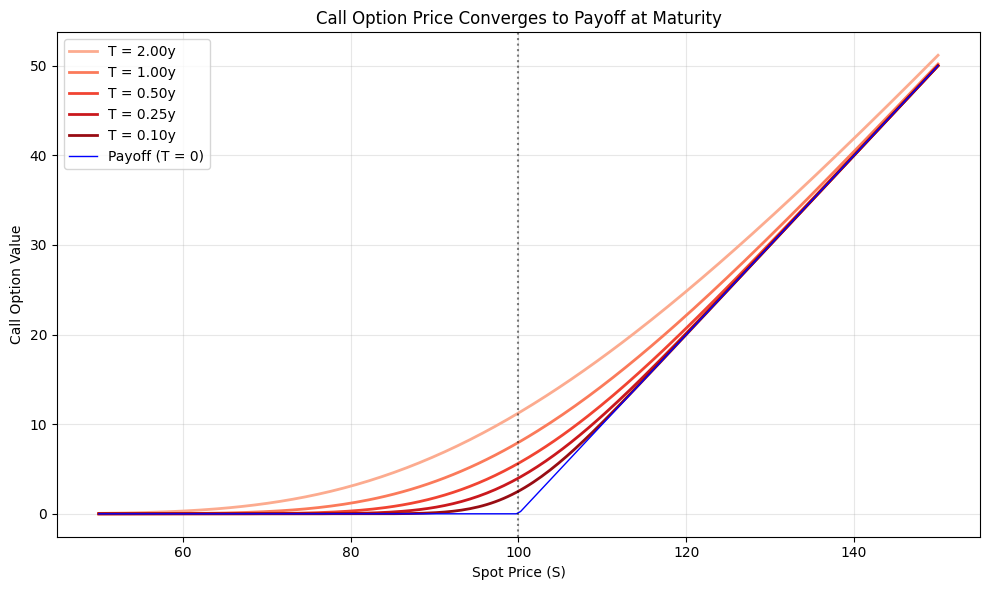

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    """Calculate the Black-Scholes price of a European call option."""
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Parameters
K = 100          # Strike price
r = 0       # Risk-free rate
sigma = 0.2      # Volatility

# Maturities: from long to approaching expiry
maturities = [2.0, 1.0, 0.5, 0.25, 0.1]

# Spot prices range
S_range = np.linspace(50, 150, 200)

# Plotting
plt.figure(figsize=(10, 6))

# Plot option prices for each maturity (lighter = closer to expiry)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(maturities)))

for T, color in zip(maturities, colors):
    call_prices = [black_scholes_call(S, K, T, r, sigma) for S in S_range]
    label = f'T = {T:.2f}y' if T >= 0.1 else f'T = {int(T*365)}d'
    plt.plot(S_range, call_prices, color=color, linewidth=2, label=label)

# PAYOFF at maturity (T = 0)
payoff = np.maximum(S_range - K, 0)
plt.plot(S_range, payoff, 'b', linewidth=1, label='Payoff (T = 0)')

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel('Spot Price (S)')
plt.ylabel('Call Option Value')
plt.title('Call Option Price Converges to Payoff at Maturity')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
print("If rates are flat, the PV of the option converges to the payoff at expiry.")
plt.show()


---

# Delta $\Delta$


$$\Delta_{\text{call}} = N(d_1) \quad \text{where} \quad d_1 = \frac{\ln(S/K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$

$$\Delta_{\text{put}} = N(d_1) - 1 = -N(-d_1)$$

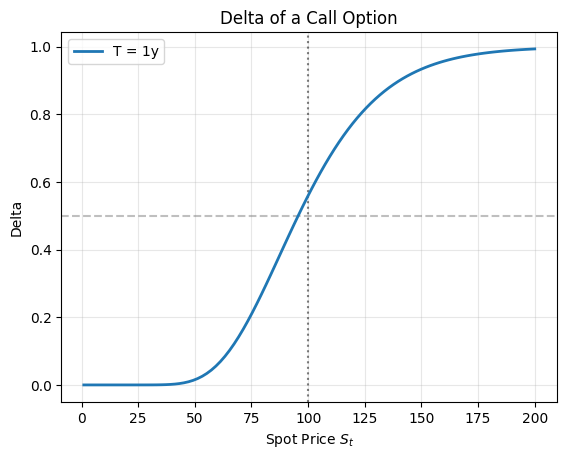

In [33]:
def delta_call(S, K, T, r, sigma):
    """
    Compute the delta of a call option using the Black-Scholes formula.
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

S=np.linspace(1,200,100)
K=100
T=1
r=0
sigma=0.3

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.plot(S, delta_call(S, K, T, r, sigma), linewidth=2, label=f'T = {T}y')
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Delta")
plt.title("Delta of a Call Option")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**ATM:** $\Delta_c \approx 0.5$

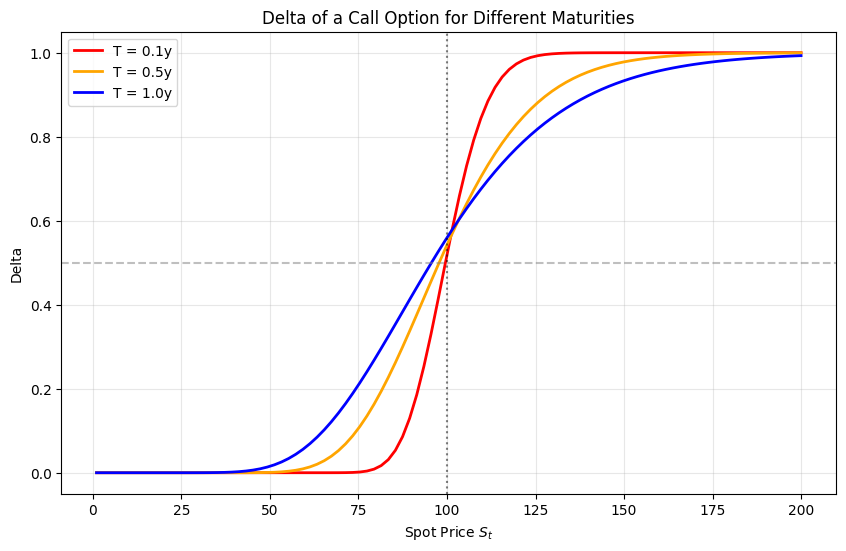

In [25]:
# Maturities
maturities = [0.1, 0.5, 1.0]  # t1 < t2 < t3
colors = ['red', 'orange', 'blue']

plt.figure(figsize=(10, 6))

for T, color in zip(maturities, colors):
    plt.plot(S, delta_call(S, K, T, r, sigma), color=color, linewidth=2, label=f'T = {T}y')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Delta")
plt.title("Delta of a Call Option for Different Maturities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

$$\text{For } T_1 < T_2: \quad \left| \frac{\partial \Delta}{\partial S} \right|_{T_1} > \left| \frac{\partial \Delta}{\partial S} \right|_{T_2}$$

$$T_1 < T_2 \implies \Delta_{T_1}(S) \text{ is steeper around } S = K$$


$$\lim_{T \to 0} \Delta_{\text{call}}(S) = \mathbf{1}_{S > K} = 
\begin{cases} 
1 & \text{if } S > K \\
0 & \text{if } S < K
\end{cases}$$


### Effect of T and σ on Delta

| Change | Effect on Delta curve |
|--------|----------------------|
| ↑ T or ↑ σ | Smoother, less steep transition around ATM |
| ↓ T or ↓ σ | Steeper, more step-like at $S = K$ |

As $T \to 0$ or $\sigma \to 0$:

$$\Delta_{\text{call}} \to \mathbf{1}_{S > K}$$

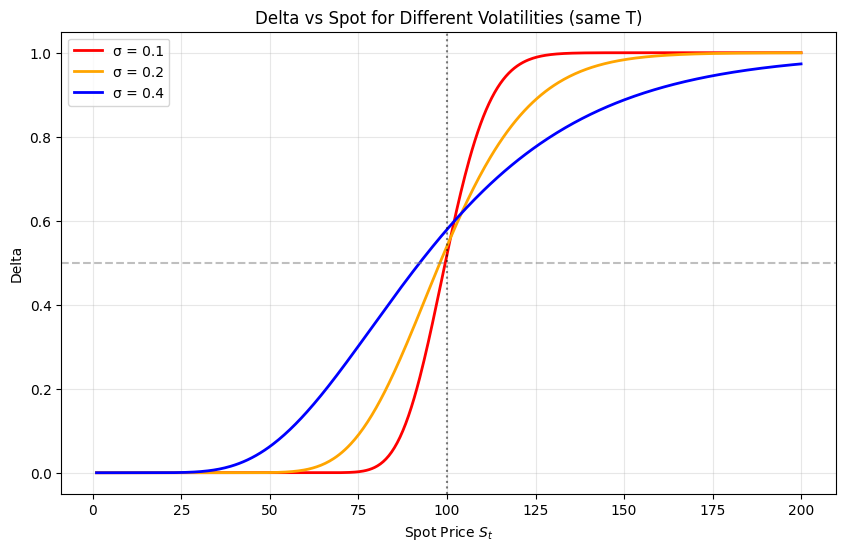

In [49]:
# Volatilities
vols = [0.1, 0.2, 0.4]
colors = ['red', 'orange', 'blue']

S = np.linspace(1, 200, 500)
K = 100
T = 1
r = 0

plt.figure(figsize=(10, 6))

for sigma, color in zip(vols, colors):
    plt.plot(S, delta_call(S, K, T, r, sigma), color=color, linewidth=2, label=f'σ = {sigma}')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Delta")
plt.title("Delta vs Spot for Different Volatilities (same T)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

## Gamma

**Gamma** = the rate of change of Delta with respect to spot price:

$$\Gamma = \frac{\partial \Delta}{\partial S} = \frac{\partial^2 C}{\partial S^2}$$

### Practical interpretation

| Gamma | Interpretation |
|-------|----------------|
| **High Γ** (ATM, short T) | Delta changes rapidly → need to rehedge frequently |
| **Low Γ** (ITM/OTM, long T) | Delta stable → less rebalancing needed |


- **Gamma is highest ATM** → Delta is most sensitive at $S = K$
- **Gamma increases as T → 0** → Delta becomes a step function, gamma becomes a spike
- **Gamma risk** = cost of rehedging; option sellers are "short gamma" (they lose from big moves)

- **Long gamma**: you benefit from large moves (rebalancing profits)
- **Short gamma**: you suffer from large moves (rebalancing costs)

$$\text{P\&L from gamma} \approx \frac{1}{2} \Gamma \cdot (\Delta S)^2$$

### Under Black-Scholes, the gamma is given by:

$$\Gamma_{\text{call}}=\Gamma_{\text{put}} = \frac{\phi(d_1)}{S \cdot \sigma \cdot \sqrt{T}} = \frac{e^{-\frac{d_1^2}{2}}}{S \cdot \sigma \cdot \sqrt{2\pi T}}$$

with $$d_1 = \frac{\ln(S/K) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$$

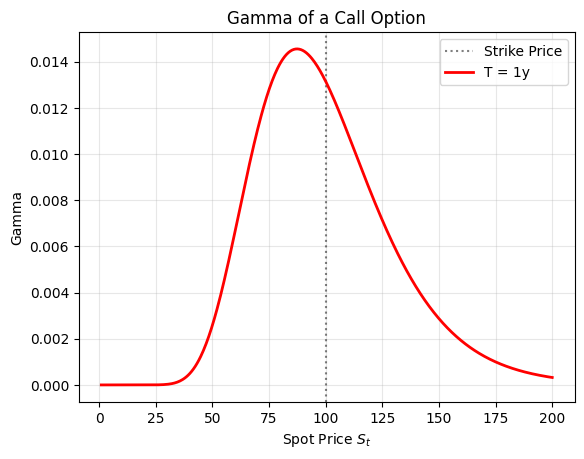

In [47]:
def gamma_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return np.exp(-0.5 * d1**2) / (S * sigma * np.sqrt(2 * np.pi * T))



S = np.linspace(1, 200, 500)  
K=100
T=1
r=0
sigma=0.3

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5, label='Strike Price')
plt.plot(S, gamma_call(S, K, T, r, sigma), color="red", linewidth=2, label=f'T = {T}y')
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Gamma")
plt.title("Gamma of a Call Option")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

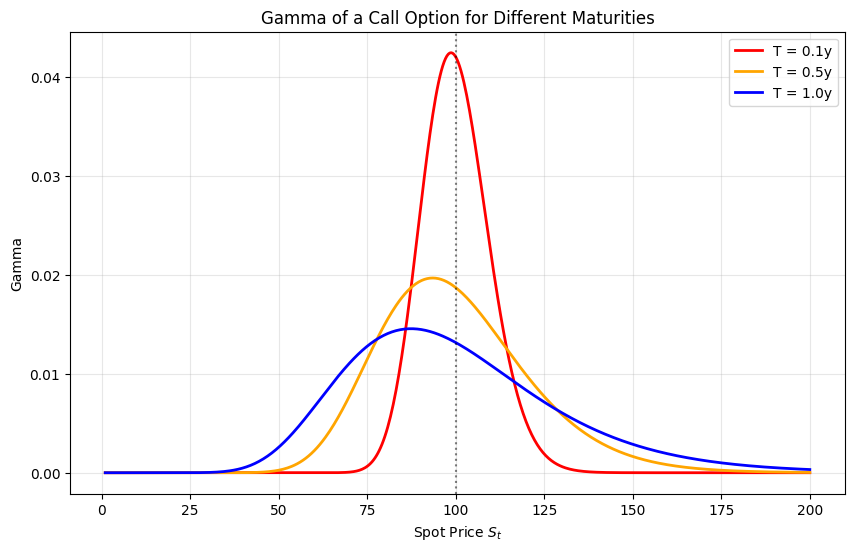

In [43]:
# Maturities
maturities = [0.1, 0.5, 1.0]  # t1 < t2 < t3
colors = ['red', 'orange', 'blue']

plt.figure(figsize=(10, 6))

for T, color in zip(maturities, colors):
    plt.plot(S, gamma_call(S, K, T, r, sigma), color=color, linewidth=2, label=f'T = {T}y')

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Gamma")
plt.title("Gamma of a Call Option for Different Maturities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

$$T_1 < T_2 \implies \Gamma_{T_1}(S=K) > \Gamma_{T_2}(S=K)$$

$$\lim_{T \to 0} \Gamma(S) = 
\begin{cases} 
+\infty & \text{if } S = K \\
0 & \text{if } S \neq K
\end{cases}
\quad \text{(Dirac-like behavior)}$$

### Effect of T and σ on Gamma

Both increasing **maturity T** and **volatility σ** have the same effect on gamma:

$$\Gamma \propto \frac{1}{\sigma\sqrt{T}}$$

| Change | Effect on Gamma |
|--------|-----------------|
| ↑ T or ↑ σ | Lower, flatter curve |
| ↓ T or ↓ σ | Higher, sharper peak at ATM |

**Intuition**: More uncertainty spreads sensitivity across a wider range of spot prices.

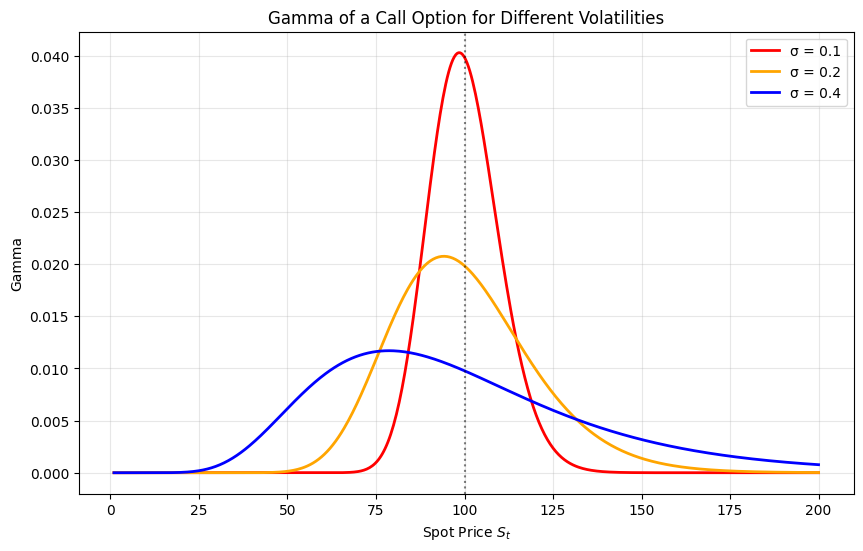

In [48]:
# Volatilities
vols = [0.1, 0.2, 0.4]  # σ1 < σ2 < σ3
colors = ['red', 'orange', 'blue']

S = np.linspace(1, 200, 500)
K = 100
T = 1
r = 0

plt.figure(figsize=(10, 6))

for sigma, color in zip(vols, colors):
    plt.plot(S, gamma_call(S, K, T, r, sigma), color=color, linewidth=2, label=f'σ = {sigma}')

plt.axvline(x=K, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Spot Price $S_t$")
plt.ylabel("Gamma")
plt.title("Gamma of a Call Option for Different Volatilities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()